# Assignment 2 — Georgian Spellcheck
## `inference.ipynb`

This notebook is **fully self-contained** — it only needs:
- `georgian_spellcheck_model.pt` — the trained checkpoint
- Standard PyTorch (no training dependencies)

It implements the required function:
```python
def correct_word(word: str, model_path: str) -> str:
    """Takes a potentially misspelled Georgian word and returns the corrected version."""
```
and demonstrates it on 23 examples covering all error types.

In [1]:
import json
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
MODEL_PATH = "/kaggle/input/models/giorgicheishvili/georgian-spellchecker/pytorch/default/1/georgian_spellcheck_model.pt"   #  update path if needed

Device : cuda


## 1 — Model Architecture *(must match training exactly)*

The checkpoint stores all hyperparameters. We reconstruct the model
from those stored values — no manual configuration needed.

In [2]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid: int, dec_hid: int):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid, dec_hid, bias=False)
        self.W_dec = nn.Linear(dec_hid, dec_hid, bias=False)
        self.v     = nn.Linear(dec_hid, 1,       bias=False)

    def forward(self, enc_out, dec_hid, src_mask):
        energy  = torch.tanh(self.W_enc(enc_out) + self.W_dec(dec_hid).unsqueeze(1))
        scores  = self.v(energy).squeeze(-1)
        scores  = scores.masked_fill(src_mask, float("-inf"))
        attn_w  = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out).squeeze(1)
        return context, attn_w


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, pad_idx):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru   = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        emb    = self.dropout(self.embed(src))
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, hid = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True,
                                     total_length=src.size(1))
        hid = torch.tanh(self.fc(torch.cat([hid[-2], hid[-1]], dim=1)))
        return out, hid


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hid, dec_hid, dropout, pad_idx):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.attention = BahdanauAttention(enc_hid, dec_hid)
        self.gru       = nn.GRU(embed_dim + enc_hid, dec_hid,
                                num_layers=1, batch_first=True)
        self.fc_out    = nn.Linear(dec_hid, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def step(self, token, hid, enc_out, src_mask):
        emb      = self.dropout(self.embed(token.unsqueeze(1)))
        ctx, attn = self.attention(enc_out, hid.squeeze(0), src_mask)
        gru_in   = torch.cat([emb, ctx.unsqueeze(1)], dim=2)
        out, hid = self.gru(gru_in, hid)
        logits   = self.fc_out(out.squeeze(1))
        return logits, hid, attn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx, sos_idx, eos_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx

    def _src_mask(self, src):
        return src == self.pad_idx

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=25):
        self.eval()
        enc_out, hid = self.encoder(src, src_lens)
        mask  = self._src_mask(src)
        hid   = hid.unsqueeze(0)
        token = torch.full((src.size(0),), self.sos_idx,
                           dtype=torch.long, device=src.device)
        preds, attns = [], []
        done = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits, hid, attn = self.decoder.step(token, hid, enc_out, mask)
            token = logits.argmax(dim=-1)
            preds.append(token)
            attns.append(attn)
            done |= (token == self.eos_idx)
            if done.all():
                break

        return torch.stack(preds, dim=1), torch.stack(attns, dim=1)


print("Model architecture defined ✓")

Model architecture defined ✓


## 2 — `correct_word` Function  *(assignment requirement)*

In [3]:
def _load_model(model_path: str):
    """
    Load checkpoint and reconstruct model from stored hyperparameters.
    Returns (model, char2idx, idx2char, special_token_indices, max_len).
    All architecture config is read from the checkpoint — nothing is hardcoded.
    """
    ckpt = torch.load(model_path, map_location=DEVICE)

    hp         = ckpt["hparams"]
    char_vocab = ckpt["char_vocab"]

    pad_idx = char_vocab["PAD_IDX"]
    sos_idx = char_vocab["SOS_IDX"]
    eos_idx = char_vocab["EOS_IDX"]
    unk_idx = char_vocab["UNK_IDX"]
    max_len = hp["max_len"]

    enc_hid = hp["hidden_dim"] * 2   # bidirectional

    encoder = Encoder(
        vocab_size=hp["vocab_size"],
        embed_dim=hp["embed_dim"],
        hidden_dim=hp["hidden_dim"],
        n_layers=hp["enc_layers"],
        dropout=hp["dropout"],
        pad_idx=pad_idx,
    )
    decoder = Decoder(
        vocab_size=hp["vocab_size"],
        embed_dim=hp["embed_dim"],
        enc_hid=enc_hid,
        dec_hid=hp["hidden_dim"],
        dropout=hp["dropout"],
        pad_idx=pad_idx,
    )
    model = Seq2Seq(encoder, decoder, pad_idx, sos_idx, eos_idx).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    char2idx = char_vocab["char2idx"]
    idx2char = {int(k): v for k, v in char_vocab["idx2char"].items()}

    return model, char2idx, idx2char, unk_idx, pad_idx, sos_idx, eos_idx, max_len


def correct_word(word: str, model_path: str) -> str:
    """
    Takes a potentially misspelled Georgian word and returns the corrected version.

    Args:
        word       : input word (may be misspelled or already correct)
        model_path : path to the .pt checkpoint file

    Returns:
        Corrected Georgian word string.
    """
    model, char2idx, idx2char, unk_idx, pad_idx, sos_idx, eos_idx, max_len = (
        _load_model(model_path)
    )

    # Encode
    ids     = [char2idx.get(c, unk_idx) for c in word[:max_len]]
    ids    += [pad_idx] * (max_len - len(ids))
    src     = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([min(len(word), max_len)], dtype=torch.long)

    # Decode
    preds, _ = model.greedy_decode(src, src_len, max_len=max_len)

    # Convert indices → string
    result = []
    for i in preds[0].tolist():
        if i == eos_idx:
            break
        if i not in (pad_idx, sos_idx):
            result.append(idx2char.get(i, "?"))
    return "".join(result)


print("correct_word() defined ✓")
print()
# Quick smoke test
test = correct_word("პროგამა", MODEL_PATH)
print(f"Smoke test: პროგამა → {test}")
print("(Expected: პროგრამა)")

correct_word() defined ✓

Smoke test: პროგამა → პროგრამა
(Expected: პროგრამა)


## 3 — Batch Inference Helper

`correct_word` reloads the model on every call as required by the assignment signature.  
For the demonstration below we use a batch helper that loads the model once.

In [4]:
# Load model once for the demonstration
_model, _char2idx, _idx2char, _unk_idx, _pad_idx, _sos_idx, _eos_idx, _max_len = (
    _load_model(MODEL_PATH)
)

ckpt_info = torch.load(MODEL_PATH, map_location="cpu")
print(f"Checkpoint : epoch {ckpt_info['epoch']}")
print(f"Val loss   : {ckpt_info['val_loss']:.4f}")
print(f"Val acc    : {ckpt_info.get('val_acc', 0)*100:.1f}%")
print(f"Hparams    : {ckpt_info['hparams']}")
n_params = sum(p.numel() for p in _model.parameters())
print(f"Parameters : {n_params:,}")


def _encode_word(word):
    ids  = [_char2idx.get(c, _unk_idx) for c in word[:_max_len]]
    ids += [_pad_idx] * (_max_len - len(ids))
    return ids, min(len(word), _max_len)


def _decode_ids(ids):
    out = []
    for i in ids:
        i = int(i)
        if i == _eos_idx: break
        if i not in (_pad_idx, _sos_idx):
            out.append(_idx2char.get(i, "?"))
    return "".join(out)


def correct_batch(words: list[str]) -> list[str]:
    """Correct a list of words in a single forward pass."""
    encoded = [_encode_word(w) for w in words]
    src     = torch.tensor([e[0] for e in encoded], dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([e[1] for e in encoded], dtype=torch.long)
    preds, _ = _model.greedy_decode(src, src_len, max_len=_max_len)
    return [_decode_ids(preds[i].tolist()) for i in range(len(words))]


print("\nBatch helper ready ✓")

Checkpoint : epoch 15
Val loss   : 0.1612
Val acc    : 53.1%
Hparams    : {'embed_dim': 128, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.1, 'vocab_size': 43, 'max_len': 25}
Parameters : 2,815,531

Batch helper ready ✓


## 4 — Demonstration: 23 Examples

Covering all error types: **already correct**, **omission**, **keyboard swap**,
**transposition**, **phonetic confusion**, and **insertion** (extra character).

In [5]:
test_cases = [
    # ── Already correct (8) ────────────────────────────────────────────────
    ("გამარჯობა",    "გამარჯობა",    "correct"),
    ("თბილისი",      "თბილისი",      "correct"),
    ("საქართველო",   "საქართველო",   "correct"),
    ("კომპიუტერი",   "კომპიუტერი",   "correct"),
    ("სკოლა",        "სკოლა",        "correct"),
    ("მასწავლებელი", "მასწავლებელი", "correct"),
    ("წიგნი",        "წიგნი",        "correct"),
    ("ქართული",      "ქართული",      "correct"),
    # ── Omission — missing character (4) ───────────────────────────────────
    ("პროგამა",      "პროგრამა",     "omission"),
    ("გამრჯობა",     "გამარჯობა",    "omission"),
    ("კომპიუტრი",    "კომპიუტერი",   "omission"),
    ("საქრთველო",    "საქართველო",   "omission"),
    # ── Keyboard swap — adjacent key (4) ───────────────────────────────────
    ("გამარჰობა",    "გამარჯობა",    "keyboard"),
    ("წიბნი",        "წიგნი",        "keyboard"),
    ("სახეიბ",       "სახელი",       "keyboard"),
    ("სქოლა",        "სკოლა",        "keyboard"),
    # ── Transposition — swapped adjacent chars (2) ─────────────────────────
    ("ბთილისი",      "თბილისი",      "transposition"),
    ("მასწვალებელი", "მასწავლებელი", "transposition"),
    # ── Phonetic confusion — ejective vs aspirate (2) ──────────────────────
    ("ქარგი",        "კარგი",        "phonetic"),
    ("ქომპიუტერი",   "კომპიუტერი",   "phonetic"),
    # ── Insertion — spurious extra character (3) ───────────────────────────
    ("სკოლაა",       "სკოლა",        "insertion"),
    ("ენაი",         "ენა",          "insertion"),
    ("წიგნიი",       "წიგნი",        "insertion"),
]

inputs   = [t[0] for t in test_cases]
expected = [t[1] for t in test_cases]
etypes   = [t[2] for t in test_cases]

predictions = correct_batch(inputs)

# ── Results table ──────────────────────────────────────────────────────────
TYPE_COLORS = {
    "correct":      "\033[94m",   # blue
    "omission":     "\033[92m",   # green
    "keyboard":     "\033[93m",   # yellow
    "transposition":"\033[95m",   # magenta
    "phonetic":     "\033[96m",   # cyan
    "insertion":    "\033[91m",   # red
}
RESET = "\033[0m"

print(f"{'#':>3}  {'TYPE':<14} {'INPUT':<24} {'PREDICTED':<24} {'EXPECTED':<24} {'PASS?'}")
print("─" * 97)

results_by_type = {}
for i, (inp, pred, exp, etype) in enumerate(zip(inputs, predictions, expected, etypes), 1):
    ok   = pred == exp
    mark = "✓" if ok else "✗"
    col  = TYPE_COLORS.get(etype, "")
    print(f"{i:>3}  {col}{etype:<14}{RESET} {inp:<24} {pred:<24} {exp:<24} {mark}")
    results_by_type.setdefault(etype, []).append(ok)

print()
print("─" * 97)
total_ok = sum(pred == exp for pred, exp in zip(predictions, expected))
print(f"\nOverall: {total_ok}/{len(test_cases)} ({total_ok/len(test_cases)*100:.0f}%)")
print()
print(f"{'TYPE':<16} {'PASS/TOTAL':>12}  {'ACC':>6}")
print("─" * 38)
for etype, results in results_by_type.items():
    p = sum(results); t = len(results)
    print(f"{etype:<16} {p:>5}/{t:<5}  {p/t*100:>5.0f}%")

  #  TYPE           INPUT                    PREDICTED                EXPECTED                 PASS?
─────────────────────────────────────────────────────────────────────────────────────────────────
  1  correct        გამარჯობა                გამარჯობა                გამარჯობა                ✓
  2  correct        თბილისი                  თბილისი                  თბილისი                  ✓
  3  correct        საქართველო               საქართველო               საქართველო               ✓
  4  correct        კომპიუტერი               კომპიუტერი               კომპიუტერი               ✓
  5  correct        სკოლა                    სკოლა                    სკოლა                    ✓
  6  correct        მასწავლებელი             მასწავლებელი             მასწავლებელი             ✓
  7  correct        წიგნი                    წიგნი                    წიგნი                    ✓
  8  correct        ქართული                  ქართული                  ქართული                  ✓
  9  omission       პროგა

## 5 — Results Visualisation

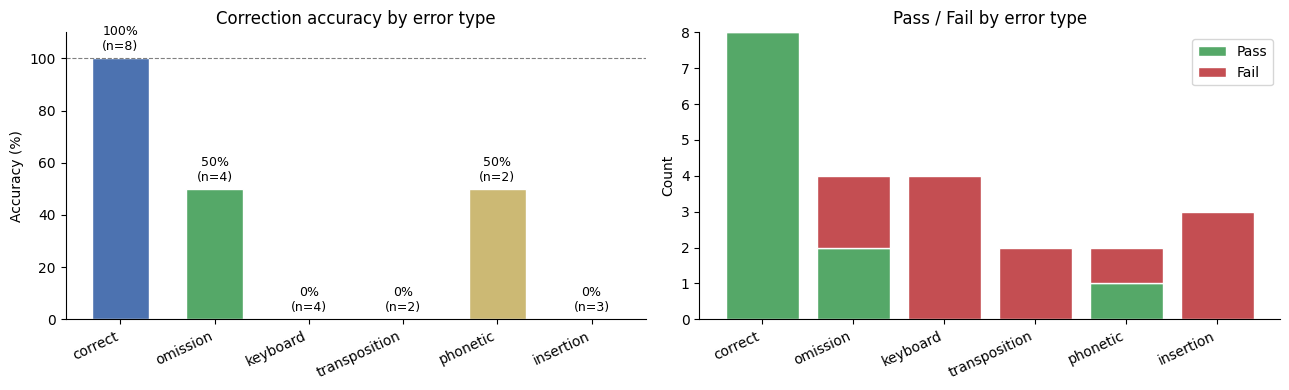

In [6]:
# ── Bar chart: accuracy by error type ─────────────────────────────────────
types  = list(results_by_type.keys())
accs   = [sum(v)/len(v)*100 for v in results_by_type.values()]
totals = [len(v) for v in results_by_type.values()]
colors = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974","#64B5CD"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(types, accs, color=colors[:len(types)], edgecolor="white", width=0.6)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Correction accuracy by error type")
axes[0].axhline(100, color="grey", ls="--", lw=0.8)
for bar, acc, tot in zip(bars, accs, totals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"{acc:.0f}%\n(n={tot})", ha="center", va="bottom", fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right")

# ── Pass/fail breakdown ────────────────────────────────────────────────────
pass_counts = [sum(v)         for v in results_by_type.values()]
fail_counts = [len(v)-sum(v)  for v in results_by_type.values()]
x = range(len(types))
axes[1].bar(x, pass_counts, label="Pass", color="#55A868", edgecolor="white")
axes[1].bar(x, fail_counts, bottom=pass_counts, label="Fail", color="#C44E52", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(types, rotation=25, ha="right")
axes[1].set_ylabel("Count"); axes[1].set_title("Pass / Fail by error type")
axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("inference_results.png", dpi=120)
plt.show()

## 6 — Attention Visualisation

The heatmap shows which input characters the decoder focused on at each output
generation step. A well-trained model should show a near-diagonal pattern for
correct words (attend to position *i* when generating position *i*) and
a shifted diagonal for error corrections (attend to the correct source position
even when the input is corrupted).

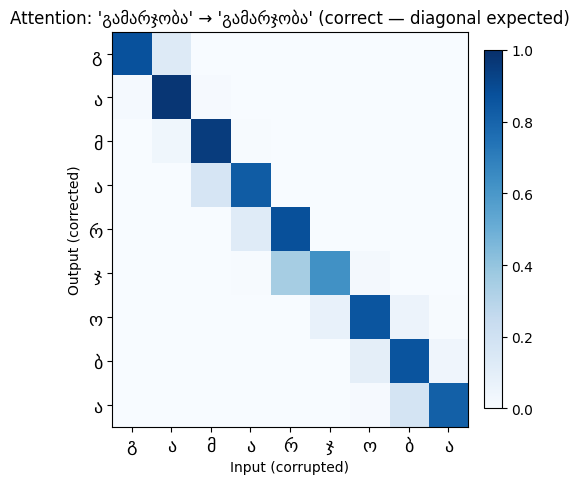

  გამარჯობა → გამარჯობა


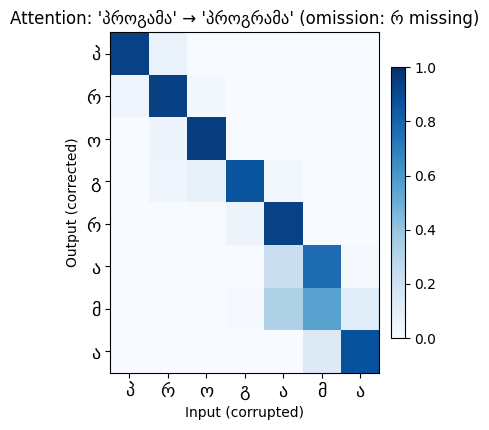

  პროგამა → პროგრამა


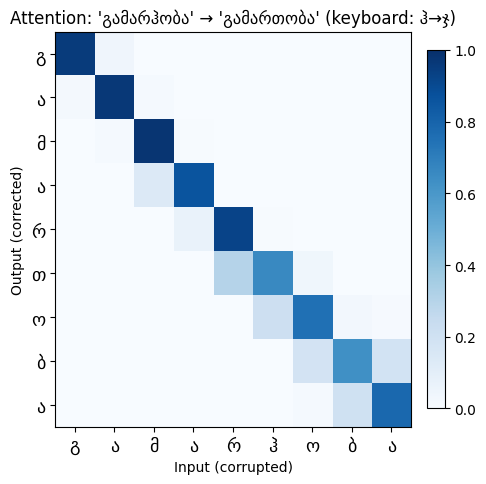

  გამარჰობა → გამართობა


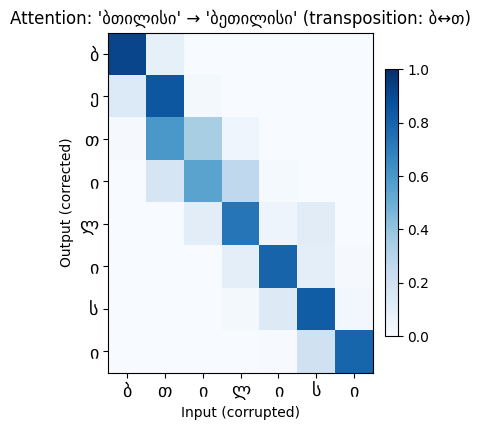

  ბთილისი → ბეთილისი


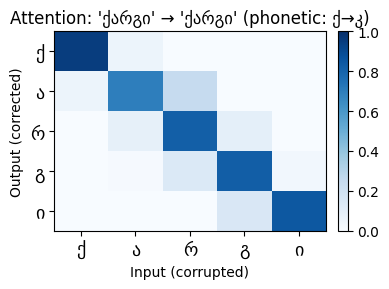

  ქარგი → ქარგი


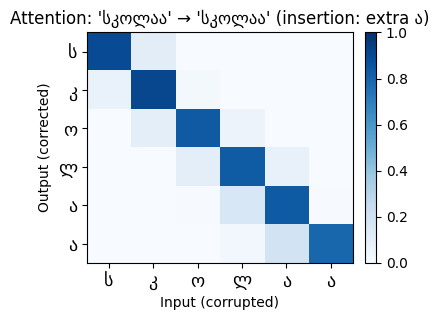

  სკოლაა → სკოლაა


In [11]:
def plot_attention(word: str, title_suffix: str = ""):
    """Plot the attention matrix for a single word."""
    ids, slen = _encode_word(word)
    src     = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([slen], dtype=torch.long)

    preds, attns = _model.greedy_decode(src, src_len, max_len=_max_len)

    pred_word = _decode_ids(preds[0].tolist())
    # attns: (1, tgt_len, src_len)
    attn_matrix = attns[0].cpu().numpy()   # (tgt_steps, src_len)

    # Trim to actual lengths
    n_out = len(pred_word)
    n_in  = slen
    attn_trimmed = attn_matrix[:n_out, :n_in]

    fig, ax = plt.subplots(figsize=(max(4, n_in*0.55), max(3, n_out*0.55)))
    im = ax.imshow(attn_trimmed, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(n_in));  ax.set_xticklabels(list(word[:n_in]),  fontsize=13)
    ax.set_yticks(range(n_out)); ax.set_yticklabels(list(pred_word), fontsize=13)
    ax.set_xlabel("Input (corrupted)")
    ax.set_ylabel("Output (corrected)")
    ax.set_title(f"Attention: '{word}' → '{pred_word}' {title_suffix}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    print(f"  {word} → {pred_word}")


# Show attention for a representative sample of each type
attention_demos = [
    ("გამარჯობა",  "(correct — diagonal expected)"),
    ("პროგამა",    "(omission: რ missing)"),
    ("გამარჰობა",  "(keyboard: ჰ→ჯ)"),
    ("ბთილისი",    "(transposition: ბ↔თ)"),
    ("ქარგი",      "(phonetic: ქ→კ)"),
    ("სკოლაა",     "(insertion: extra ა)"),
]

for word, label in attention_demos:
    plot_attention(word, label)

## 7 — Try Your Own Words

In [12]:
# Add any Georgian words here to test the model
custom_words = [
    "ბანანი",       # should stay correct
    "ბნნი",         # omission
    "ქართველი",     # should stay correct
    "ქართვეი",      # omission
    "უნივერსიტეტი", # should stay correct
]

print(f"{'INPUT':<28} → PREDICTED")
print("─"*45)
for w in custom_words:
    pred = correct_word(w, MODEL_PATH)
    print(f"{w:<28}   {pred}")

INPUT                        → PREDICTED
─────────────────────────────────────────────
ბანანი                         ბანანი
ბნნი                           ბანნი
ქართველი                       ქართველი
ქართვეი                        ქართველი
უნივერსიტეტი                   უნივერსიტეტი


## 8 — `correct_word` Showcase  *(assignment function, called directly)*

Demonstrating the exact signature required by the assignment:

In [13]:
# Calling the exact assignment-required signature
demo_pairs = [
    "გამარჰონა",   # example from assignment brief
    "თბილისი",     # already correct — from assignment brief
    "პროგამა",     # omission — from assignment brief
    "საქართველო",  # already correct
    "კომპიუტრი",   # omission
    "ქარგი",       # phonetic
    "ბთილისი",     # transposition
    "სკოლაა",      # insertion
]

print("correct_word(word, model_path) — direct calls:")
print(f"  {'WORD':<28} → RESULT")
print("  " + "─"*42)
for word in demo_pairs:
    result = correct_word(word, MODEL_PATH)
    print(f"  {word:<28}   {result}")

correct_word(word, model_path) — direct calls:
  WORD                         → RESULT
  ──────────────────────────────────────────
  გამარჰონა                      გამარბონა
  თბილისი                        თბილისი
  პროგამა                        პროგრამა
  საქართველო                     საქართველო
  კომპიუტრი                      კომპიუტური
  ქარგი                          ქარგი
  ბთილისი                        ბეთილისი
  სკოლაა                         სკოლაა
